In [1]:
import xml.etree.ElementTree as ET
import numpy as np
from scipy.integrate import quad

tree = ET.parse("AeroTech_E12-RCJ.rse")
root = tree.getroot()

curve_times = []
thrust = []
prop_mass = []

for point in root.iter("eng-data"):
    curve_times.append(float(point.get("t")))
    thrust.append(float(point.get("f")))
    prop_mass.append(float(point.get("m")))

def totalmassdt(t):
    current_propellant_mass = (np.interp(t, curve_times, prop_mass))/1000
    total_mass = 0.32 + current_propellant_mass
    return total_mass
def thrustdt(t):
    current_thrust = np.interp(t, curve_times, thrust)
    return current_thrust

print("total mass at t=1 : ", totalmassdt(1), "kg")
print("thrust at t=1 : ", thrustdt(1), "N")

total mass at t=1 :  0.3360428162790698 kg
thrust at t=1 :  15.71498449612403 N


In [2]:
def center_of_mass(t):
    def tail_densitydt (t):
        #i need it to give me the value of tail density varied with time, starting from 2.10799219229.
        current_propellant_mass = (np.interp(t, curve_times, prop_mass))/1000
        tail_density = 1.67942076371 + (current_propellant_mass / 0.07)
        return tail_density

    def tail_int_top(x):
        return (x * tail_densitydt(t))

    def integrand_top(x):
        return (x * (0.833894667965 * ((np.cos((100/5.08) * (x-(np.pi/4)+0.125)))**2 + np.sin((100/5.08) * (x+(np.pi/6)+0.125)) + 1)))
    def integrand_bottom(x):
        return (0.833894667965 * ((np.cos((100/5.08) * (x-(np.pi/4)+0.125)))**2 + np.sin((100/5.08) * (x+(np.pi/6)+0.125)) + 1))

    h_top, error_h_top = quad(tail_int_top,0,0.07)
    h_bottom = 0.07 * tail_densitydt(t)
    f_top, error_f_top = quad(integrand_top, 0.07, 0.25)
    f_bottom, error_f_bottom = quad(integrand_bottom, 0.07, 0.25)

    def cm_calc():
        center_of_mass = ((h_top + f_top)/(h_bottom + f_bottom))
        return center_of_mass
    
    time_mass_center = cm_calc()
    return (time_mass_center)


print (center_of_mass(0))
#gives center of mass as function of time

def tail_plus_f_mass(t):
    
    def tail_densitydt (t):
        #i need it to give me the value of tail density varied with time, starting from 2.10799219229.
        current_propellant_mass = (np.interp(t, curve_times, prop_mass))/1000
        tail_density = 1.67942076371 + (current_propellant_mass / 0.07)
        return tail_density
    
    def tail_int_top(x):
        return (x * tail_densitydt(t))

    def integrand_bottom(x):
        return (0.833894667965 * ((np.cos((100/5.08) * (x-(np.pi/4)+0.125)))**2 + np.sin((100/5.08) * (x+(np.pi/6)+0.125)) + 1))
    f_bottom, error_f_bottom = quad(integrand_bottom, 0.07, 0.25)
    h_bottom = 0.07 * tail_densitydt(t)
    mass_of_f = f_bottom
    mass_of_tail = h_bottom
    mass = mass_of_tail + mass_of_f
    return mass

    
def moment_of_yawpitch_inertia(t):
    def tail_densitydt (t):
        #i need it to give me the value of tail density varied with time, starting from 2.10799219229.
        current_propellant_mass = (np.interp(t, curve_times, prop_mass))/1000
        tail_density = 1.67942076371 + (current_propellant_mass / 0.07)
        return tail_density

    def tail_int_top(x):
        return (x * tail_densitydt(t))

    def integrand_top(x):
        return (x * (0.833894667965 * ((np.cos((100/5.08) * (x-(np.pi/4)+0.125)))**2 + np.sin((100/5.08) * (x+(np.pi/6)+0.125)) + 1)))
    def integrand_bottom(x):
        return (0.833894667965 * ((np.cos((100/5.08) * (x-(np.pi/4)+0.125)))**2 + np.sin((100/5.08) * (x+(np.pi/6)+0.125)) + 1))

    h_top, error_h_top = quad(tail_int_top,0,0.07)
    h_bottom = 0.07 * tail_densitydt(t)
    f_top, error_f_top = quad(integrand_top, 0.07, 0.25)
    f_bottom, error_f_bottom = quad(integrand_bottom, 0.07, 0.25)

    def cm_calc():
        center_of_mass = ((h_top + f_top)/(h_bottom + f_bottom))
        return center_of_mass

    def mi_int_tail(x):
        return ((x**2) * tail_densitydt(t))

    def mi_integrand(x):
        return ((x**2) * (0.833894667965 * ((np.cos((100/5.08) * (x-(np.pi/4)+0.125)))**2 + np.sin((100/5.08) * (x+(np.pi/6)+0.125)) + 1)))

    moment_of_inertia_dt, moment_of_inertia_dt_error = quad(mi_int_tail, 0, 0.07)
    moment_of_inertia_sinusoidal, moment_of_inertia_sinusoidal_error = quad(mi_integrand, 0.07, 0.25)

    def mi_base():
        moment_of_inertia_base = moment_of_inertia_dt + moment_of_inertia_sinusoidal
        return moment_of_inertia_base

    def parallel_axis_theorem():
        mi_calc = (mi_base()) - ((center_of_mass(t))**2) * (h_bottom + f_bottom)
        return mi_calc

    moment_of_inertia_yaw_pitch = parallel_axis_theorem()
    return moment_of_inertia_yaw_pitch

def moment_of_roll_inertia(t):
    def tail_densitydt (t):
        #i need it to give me the value of tail density varied with time, starting from 2.10799219229.
        current_propellant_mass = (np.interp(t, curve_times, prop_mass))/1000
        tail_density = 1.67942076371 + (current_propellant_mass / 0.07)
        return tail_density

    def tail_int_top(x):
        return (x * tail_densitydt(t))

    def integrand_top(x):
        return (x * (0.833894667965 * ((np.cos((100/5.08) * (x-(np.pi/4)+0.125)))**2 + np.sin((100/5.08) * (x+(np.pi/6)+0.125)) + 1)))
    def integrand_bottom(x):
        return (0.833894667965 * ((np.cos((100/5.08) * (x-(np.pi/4)+0.125)))**2 + np.sin((100/5.08) * (x+(np.pi/6)+0.125)) + 1))

    h_top, error_h_top = quad(tail_int_top,0,0.07)
    h_bottom = 0.07 * tail_densitydt(t)
    f_top, error_f_top = quad(integrand_top, 0.07, 0.25)
    f_bottom, error_f_bottom = quad(integrand_bottom, 0.07, 0.25)

    def cm_calc():
        center_of_mass = ((h_top + f_top)/(h_bottom + f_bottom))
        return center_of_mass
        
    mi_due_to_aluminum_casing = 0.0000903224
    mi_due_to_electrical_components = 0.00000172042666667
    mi_due_to_gimbal = 0.0000258064

    def motor_mass(t):
        motor_mass_current = 0.0291 + (np.interp(t, curve_times, prop_mass))/1000
        return motor_mass_current

    outer_radius = 0.00900270246605
    inner_radius = np.sqrt((outer_radius**2)-((np.interp(t, curve_times, prop_mass)/1000)/(1700 * 0.07 * np.pi)))

    def integrand_dm(x):
        return (2 * np.pi * 1700 * 0.07 * (x**3))

    mi_roll_due_to_motor_dt, mi_roll_due_to_motor_dt_error = quad(integrand_dm, inner_radius, outer_radius)
        
    def moment_of_inertia_roll(t):
        roll_moment_of_inertia = mi_due_to_aluminum_casing + (2 * mi_due_to_electrical_components) + mi_due_to_gimbal + mi_roll_due_to_motor_dt
        return roll_moment_of_inertia

    calc_roll_moment_of_inertia = moment_of_inertia_roll(t)
    return calc_roll_moment_of_inertia

print (moment_of_roll_inertia(0))
def extract_angles(state):
    w, x, y, z = state[3], state[4], state[5], state[6]
    pitch = np.arcsin(2*(x*z + w*y))
    yaw   = np.arctan2(2*(x*y + w*z), 1 - 2*(y**2 + z**2))
    return pitch, yaw
print (extract_angles([0, 0, 0, 0.5, 0.5, 0.5, 0.5]))

# 1. Identity → (0, 0)
print("identity:", np.degrees(extract_angles([0,0,0, 1, 0, 0, 0])))

# 2. Pure +30° pitch: w=cos15, y=sin15
print("30 pitch:", np.degrees(extract_angles([0,0,0, np.cos(np.radians(15)), 0, np.sin(np.radians(15)), 0])))
# expect pitch≈30, yaw≈0

# 3. Pure +45° yaw: w=cos22.5, z=sin22.5
print("45 yaw:", np.degrees(extract_angles([0,0,0, np.cos(np.radians(22.5)), 0, 0, np.sin(np.radians(22.5))])))
# expect pitch≈0, yaw≈45

0.09452873124865306
0.0001207975404064779
(np.float64(1.5707963267948966), np.float64(1.5707963267948966))
identity: [0. 0.]
30 pitch: [30.  0.]
45 yaw: [ 0. 45.]


In [18]:
#Inertial Components

def gimbal_torque_pitch(theta, alpha, t):

    thrust_pitch = np.sin(theta) * thrustdt(t) * np.cos(alpha)
    torque_pitch = thrust_pitch * center_of_mass(t)
    return torque_pitch
    
def gimbal_torque_yaw(theta, alpha, t):

    thrust_yaw = np.sin(theta) * thrustdt(t) * np.sin(alpha)
    yaw_torque = thrust_yaw * center_of_mass(t)
    return yaw_torque


flywheel_Inertia = 0.00000985608
angular_accel_flywheel = 122 #Radians per second**2    
tau = -flywheel_Inertia * angular_accel_flywheel

def derivatives(state, theta, alpha, t):
    #unpack the state vector
    p, q, r, w, x, y, z = state

    mass, cm, i_roll, i_pitch_yaw = inertial_values_dt(t)
    
    I_x = inertial_values_dt(t)[2]
    I_y = inertial_values_dt(t)[3]
    I_z = I_y

    dIx_dt = np.interp(t, time_calls, roll_inertia_dt)
    dIy_dt = np.interp(t, time_calls, pitchyaw_inertia_dt)
    dIz_dt = dIy_dt

    #dIz_dt = dIy_dt = dIx_dt = 0

    #Euler  equations: Roll Pitch and yaw
    p_dot = ((I_y-I_z) * q * r - (dIx_dt * p) + tau) / I_x
    q_dot = ((I_z-I_x) * r * p - (dIy_dt * q) + gimbal_torque_pitch(theta, alpha, t)) / I_y
    r_dot = ((I_x-I_y) * p * q - (dIz_dt * r) + gimbal_torque_yaw(theta, alpha, t)) / I_z

    #Quaternion kinematics: x, y, z, w, where the magnitude of the four always equals to one.
    w_dot = 0.5 * (-x*p - y*q - z*r)
    x_dot = 0.5 * ( w*p - z*q + y*r)
    y_dot = 0.5 * ( z*p + w*q - x*r)
    z_dot = 0.5 * (-y*p + x*q + w*r)

    return [p_dot, q_dot, r_dot, w_dot, x_dot, y_dot, z_dot]

In [4]:
time_calls = np.linspace(0, 3.2, 320)
totalmass_calls = []
cm_calls = []
pitch_yaw_inertial_calls = []
roll_inertial_calls = []

for t in time_calls:
    totalmass_calls.append(tail_plus_f_mass(t))
    cm_calls.append(center_of_mass(t))
    pitch_yaw_inertial_calls.append(moment_of_yawpitch_inertia(t))
    roll_inertial_calls.append(moment_of_roll_inertia(t))

totalmass_calls = np.array(totalmass_calls)
cm_calls = np.array(cm_calls)
pitch_yaw_inertial_calls = np.array(pitch_yaw_inertial_calls)
roll_inertial_calls = np.array(roll_inertial_calls)

def inertial_values_dt(t):
    mass = np.interp(t, time_calls, totalmass_calls)
    cm = np.interp(t, time_calls, cm_calls)
    i_roll = np.interp(t, time_calls, roll_inertial_calls)
    i_pitch_yaw = np.interp(t, time_calls, pitch_yaw_inertial_calls)
    return mass, cm, i_roll, i_pitch_yaw

roll_inertia_dt = np.gradient(roll_inertial_calls, time_calls)
pitchyaw_inertia_dt = np.gradient(pitch_yaw_inertial_calls, time_calls)

In [5]:
def rk4_step (state, angle, alpha, t, dt):
    
    # 4 derivatives sampled, with double weightage to k2 and k3, across a step dt
    k1 = np.array(derivatives(state, angle, alpha, t))
    k2 = np.array(derivatives(state + 0.5 * dt * k1, angle, alpha, t + 0.5 * dt))
    k3 = np.array(derivatives(state + 0.5 * dt * k2, angle, alpha, t + 0.5 * dt))
    # Using factor of 0.5 because k2 and k3 are in the middle. Picturing a Riemann sum, k2 and k3 are the middle approx, k1 is the left side approx, and k4 is the right side approx.
    k4 = np.array(derivatives(state + dt * k3, angle, alpha, t + dt))

    # Now add the double weightage to k2 and k3 and sum it
    unnormed_state = (state + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4))
   
    # calculate the norm to renormalize the quaternion
    norm_calc = np.array(unnormed_state[3:])
    norm = np.linalg.norm(norm_calc)

    norm_quat = np.array ([1, 1, 1, norm, norm, norm, norm])
    
    new_state = unnormed_state / norm_quat
    
    return new_state

print (rk4_step ([0,0,0,1,0,0,0], 1, 45, 1, 0.01))

[-9.97708901e-02  5.16493906e+00  8.37169315e+00  9.99697500e-01
 -2.49375531e-04  1.29164160e-02  2.09287584e-02]


pitch: 4.942595076073604 yaw: 11.978816081434923
7.0
179.91613506091676


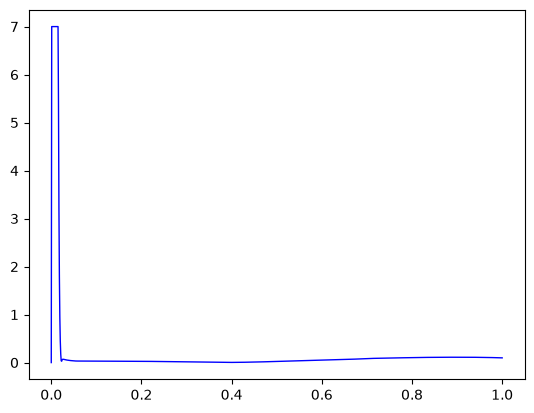

In [23]:
import matplotlib.pyplot as plt
import numpy as np


pitch_deg = 5
yaw_deg = 12
# small-angle: quaternion vector part ≈ half the rotation angle about each axis
p = np.radians(pitch_deg) / 2
y = np.radians(yaw_deg) / 2
quat = np.array([1, 0, p, y])          # [w, x, y_component, z_component]
quat = quat / np.linalg.norm(quat)     # normalize to unit length

state = np.array([0, 0, 0, quat[0], quat[1], quat[2], quat[3]])
t, dt = 0.0, 0.001

#Kp_pitch = 0.1
#Kd_pitch = 0.000105038421758594
Kp = 2.0
Kd = 1.2


states = [state]
times = [0.0]
theta_history = [0]
alpha_history = [0]

for i in range(1000):
    pitch, yaw = extract_angles(state)
    q = state[1]
    r = state [2]

    omega_roll = angular_accel_flywheel * t

    omega_precession = omega_roll * (moment_of_roll_inertia(t) / moment_of_yawpitch_inertia(t))
    Kp_effective = Kp * thrustdt(t) * center_of_mass(t)
    omega_natural = np.sqrt (Kp_effective / moment_of_yawpitch_inertia(t))

    error_pitch = 0-pitch
    pitch_correction_rads = Kp * error_pitch + Kd * (-q)

    error_yaw = 0-yaw
    yaw_correction_rads = Kp * error_yaw + Kd * (-r)

    theta = np.sqrt(pitch_correction_rads**2 + yaw_correction_rads**2)
    alpha = np.arctan2(yaw_correction_rads, pitch_correction_rads)

    theta = min(theta, np.radians(7))
    
    state = rk4_step(state, theta, alpha, t, dt)
    t += dt

    states.append(state)
    times.append(t)
    theta_history.append(theta)
    alpha_history.append(alpha)

#plt.plot(times, np.degrees(alpha_history), label='behavior', color='red', linewidth = 1)
plt.plot(times, np.degrees(theta_history), label='behavior', color='blue', linewidth = 1)

state = np.array([0, 0, 0, quat[0], quat[1], quat[2], quat[3]])
pitch, yaw = extract_angles(state)
print("pitch:", np.degrees(pitch), "yaw:", np.degrees(yaw))

print (max(np.degrees(np.abs(theta_history))))
print (max(np.degrees(np.abs(alpha_history))))

In [7]:
#Finding number of steps
dt = 0.001
time_total = 30
num_steps = int(time_total/dt)
angle = 1
alpha = 45

#Consolidate the state np.array into one cell.
state = np.array([0, 0, 0, 1, 0, 0, 0])

#Lists of time and states
times = [0.0]
states = [state]

#Loop for 30,000 times
for i in range(num_steps):
    state = rk4_step(state, angle, alpha, t, dt)      # advance one step, feed result back in
    times.append((i + 1) * dt)       # record the time
    states.append(state)             # record the state

final = states[-1]
print("Final p q r :", final[0], final [1], final [2])
print("Final quaternion :", final[3:])

Final p q r : -320.1925577084345 -935.7680063102864 1280.7087292819288
Final quaternion : [-0.82816451  0.55600845 -0.01206639  0.06966026]


In [8]:
t = 0.0
for i in range(num_steps):
    state = rk4_step(state, angle, alpha, t, dt)
    t = t + dt
    states.append(state)
    times.append(t)


KeyboardInterrupt



In [ ]:
# L_magnitudes = []

# for s in states:

#     I_x = inertial_values_dt(t)[2]
#     I_y = inertial_values_dt(t)[3]
#     I_z = I_y

#     dIx_dt = np.interp(t, time_calls, roll_inertia_dt)
#     dIy_dt = np.interp(t, time_calls, pitchyaw_inertia_dt)
#     dIz_dt = dIy_dt
    
#     p = s[0]
#     q = s[1]
#     r = s[2]
#     L = np.sqrt((I_x*p)**2 + (I_y*q)**2 + (I_z*r)**2)
#     L_magnitudes.append(L)

# #compare first and last L's
# print ("relative drift from initial:", (L_magnitudes[31000] - L_magnitudes[0])/L_magnitudes[0])
# print("First:", L_magnitudes[0])
# print("Last: ", L_magnitudes[31000])

In [ ]:
def quat_to_matrix(w, x, y, z):
    return np.array([
        [1 - 2*(y**2 + z**2),   2*(x*y - w*z),       2*(x*z + w*y)],
        [2*(x*y + w*z),         1 - 2*(x**2 + z**2), 2*(y*z - w*x)],
        [2*(x*z - w*y),         2*(y*z + w*x),       1 - 2*(x**2 + y**2)]
    ])

L_inertial_list = []

for i in range(len(states)):
    s = states[i]
    t = times[i]                          # the time for THIS step

    p, q, r, w, x, y, z = s

    # inertia at THIS step's time
    mass, cm, i_roll, i_pitch = inertial_values_dt(t)

    # angular momentum in body frame
    L_body = np.array([i_roll * p, i_pitch * q, i_pitch * r])

    # rotate into inertial frame
    R = quat_to_matrix(w, x, y, z)
    L_inertial = R @ L_body               # @ is matrix-vector multiply

    L_inertial_list.append(L_inertial)

L_inertial_list = np.array(L_inertial_list)


print(quat_to_matrix(1,0,0,0))
print(quat_to_matrix(np.sqrt(1/2), 0, 0, np.sqrt(1/2)))

print("Lx range:", L_inertial_list[:,0].min(), L_inertial_list[:,0].max())
print("Ly range:", L_inertial_list[:,1].min(), L_inertial_list[:,1].max())
print("Lz range:", L_inertial_list[:,2].min(), L_inertial_list[:,2].max())

# relative variation of the magnitude
mags = np.linalg.norm(L_inertial_list, axis=1)
print("relative drift:", (mags.max() - mags.min()) / mags.mean())
s = states[0]
quat = s[3:]
print(np.linalg.norm(quat))